# Statistics for Machine Learning — Notebook 2  
# Probability for Machine Learning

## Why this notebook matters

Machine Learning is full of uncertainty.

A model rarely says:

> This is 100% true.

Instead, it often says:

> I am 82% confident this email is spam.  
> I am 67% confident this customer will churn.  
> I am 91% confident this image contains a cat.

That confidence is probability.

Probability helps us understand:

- uncertainty
- classification confidence
- conditional relationships
- Bayes theorem
- likelihood
- model predictions
- risk-based decisions
- false positives and false negatives

---

## What you will learn

1. What probability means in ML  
2. Random experiments, sample space, and events  
3. Probability rules  
4. Union, intersection, and complement  
5. Conditional probability  
6. Independent and dependent events  
7. Bayes theorem  
8. Probability tables  
9. Expected value intuition  
10. Probability simulation using Python  
11. Classification probability  
12. Threshold-based decisions  
13. Mini project: probability-based churn decision system

# 1. Probability in Machine Learning

Probability is used when outcomes are uncertain.

Examples:

| ML Problem | Probability Meaning |
|---|---|
| Spam detection | Probability email is spam |
| Churn prediction | Probability customer will leave |
| Fraud detection | Probability transaction is fraud |
| Medical AI | Probability patient has disease |
| Image classification | Probability image belongs to class |
| Recommendation system | Probability user will click |
| Weather model | Probability it will rain |

A model's probability output helps us make decisions.

Example:

```text
P(churn = 1 | customer features) = 0.78
```

This means:

> Given this customer's data, the model estimates 78% chance of churn.

# 2. Setup

Run this cell first.

If something is missing:

```python
!pip install numpy pandas matplotlib seaborn scikit-learn ipywidgets
```

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Install it using: pip install ipywidgets")

np.random.seed(42)

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


# 3. Random experiment, sample space, and event

## Random experiment

A random experiment is a process where the outcome is uncertain.

Examples:

- tossing a coin
- rolling a dice
- customer clicking an ad
- email being spam or not spam
- patient having disease or not
- transaction being fraud or normal

## Sample space

Sample space is the set of all possible outcomes.

Example for coin toss:

```text
S = {Heads, Tails}
```

Example for dice roll:

```text
S = {1, 2, 3, 4, 5, 6}
```

## Event

An event is a subset of the sample space.

Example:

```text
Event A = rolling an even number = {2, 4, 6}
```

In [2]:
# Dice example

sample_space = [1, 2, 3, 4, 5, 6]

event_even = [2, 4, 6]
event_greater_than_4 = [5, 6]

print("Sample space:", sample_space)
print("Event even:", event_even)
print("Event greater than 4:", event_greater_than_4)

Sample space: [1, 2, 3, 4, 5, 6]
Event even: [2, 4, 6]
Event greater than 4: [5, 6]


# 4. Basic probability

Probability of an event:

```text
P(A) = number of favorable outcomes / total number of outcomes
```

For a fair dice:

```text
P(even) = 3 / 6 = 0.5
```

In [3]:
def probability(event, sample_space):
    return len(event) / len(sample_space)

p_even = probability(event_even, sample_space)
p_greater_than_4 = probability(event_greater_than_4, sample_space)

print("P(even):", p_even)
print("P(greater than 4):", p_greater_than_4)

P(even): 0.5
P(greater than 4): 0.3333333333333333


# 5. Simulation vs theory

Sometimes probability can be calculated exactly.

Sometimes we estimate probability using simulation.

Example:

If we roll a fair dice many times, the simulated probability of even numbers should get close to 0.5.

Theoretical P(even): 0.5
Simulated P(even): 0.502


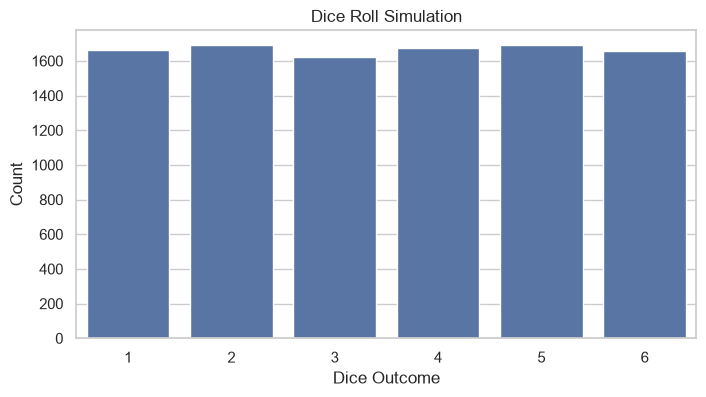

In [4]:
rolls = np.random.choice(sample_space, size=10000, replace=True)

simulated_p_even = np.mean(rolls % 2 == 0)

print("Theoretical P(even):", 0.5)
print("Simulated P(even):", simulated_p_even.round(3))

plt.figure(figsize=(8, 4))
sns.countplot(x=rolls)
plt.title("Dice Roll Simulation")
plt.xlabel("Dice Outcome")
plt.ylabel("Count")
plt.show()

# 6. Law of large numbers

As the number of trials increases, the simulated probability becomes closer to the true probability.

This idea is important because ML often learns patterns from many examples.

,trials,estimated_probability_even
0,10,0.20000
1,50,0.62000
2,100,0.49000
3,500,0.49600
4,1000,0.48400
5,5000,0.50120
6,10000,0.50270
7,50000,0.50234


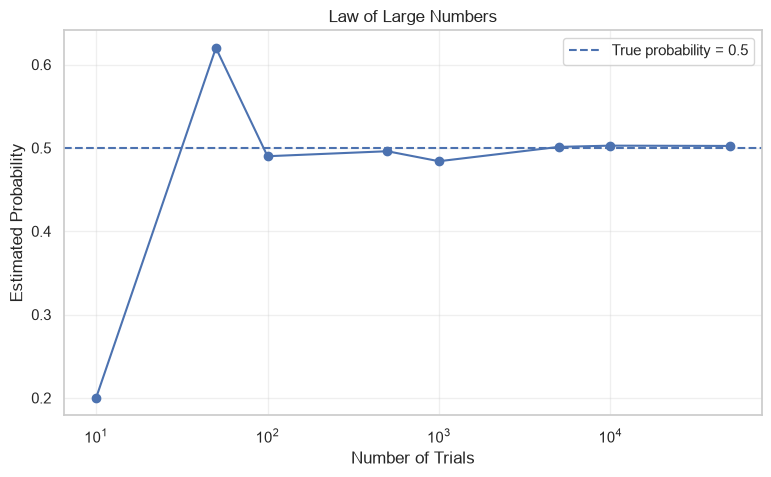

In [3]:
trial_sizes = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
estimated_probs = []

for n in trial_sizes:
    rolls = np.random.choice(sample_space, size=n, replace=True)
    estimated_probs.append(np.mean(rolls % 2 == 0))

result_df = pd.DataFrame({
    "trials": trial_sizes,
    "estimated_probability_even": estimated_probs
})

display(result_df)

plt.figure(figsize=(9, 5))
plt.plot(result_df["trials"], result_df["estimated_probability_even"], marker="o")
plt.axhline(0.5, linestyle="--", label="True probability = 0.5")
plt.xscale("log")
plt.title("Law of Large Numbers")
plt.xlabel("Number of Trials")
plt.ylabel("Estimated Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Complement rule

The complement of event A means A does not happen.

```text
P(not A) = 1 - P(A)
```

Example:

If probability of churn is 0.30:

```text
P(not churn) = 1 - 0.30 = 0.70
```

In [6]:
p_churn = 0.30
p_not_churn = 1 - p_churn

print("P(churn):", p_churn)
print("P(not churn):", p_not_churn)

P(churn): 0.3
P(not churn): 0.7


# 8. Union and intersection

Suppose we have two events:

```text
A = customer is premium
B = customer churns
```

## Intersection

A and B both happen:

```text
P(A and B)
```

Meaning:

> Probability customer is premium and churns.

## Union

A or B or both happen:

```text
P(A or B)
```

Meaning:

> Probability customer is premium or churns or both.

In [7]:
# Simple customer data

customer_data = pd.DataFrame({
    "customer_id": range(1, 11),
    "premium": [1, 1, 0, 0, 1, 0, 1, 0, 0, 1],
    "churn":   [0, 1, 0, 1, 1, 0, 0, 0, 1, 0]
})

display(customer_data)

A = customer_data["premium"] == 1
B = customer_data["churn"] == 1

p_A = A.mean()
p_B = B.mean()
p_A_and_B = (A & B).mean()
p_A_or_B = (A | B).mean()

print("P(premium):", p_A)
print("P(churn):", p_B)
print("P(premium and churn):", p_A_and_B)
print("P(premium or churn):", p_A_or_B)

,customer_id,premium,churn
0,1,1,0
1,2,1,1
2,3,0,0
3,4,0,1
4,5,1,1
5,6,0,0
6,7,1,0
7,8,0,0
8,9,0,1
9,10,1,0


P(premium): 0.5
P(churn): 0.4
P(premium and churn): 0.2
P(premium or churn): 0.7


# 9. Addition rule

For two events A and B:

```text
P(A or B) = P(A) + P(B) - P(A and B)
```

Why subtract intersection?

Because `P(A) + P(B)` counts the overlap twice.

In [8]:
p_union_formula = p_A + p_B - p_A_and_B

print("P(A or B) directly:", p_A_or_B)
print("P(A or B) using formula:", p_union_formula)

P(A or B) directly: 0.7
P(A or B) using formula: 0.7


# 10. Conditional probability

Conditional probability means probability of A given B already happened.

Formula:

```text
P(A | B) = P(A and B) / P(B)
```

Example:

```text
P(churn | premium)
```

means:

> Among premium customers, what proportion churned?

In [9]:
p_churn_given_premium = ((customer_data["churn"] == 1) & (customer_data["premium"] == 1)).sum() / (customer_data["premium"] == 1).sum()

print("P(churn | premium):", p_churn_given_premium)

P(churn | premium): 0.4


# 11. Conditional probability with a larger dataset

Now let's create a more realistic dataset.

We will calculate:

- P(churn)
- P(high support tickets)
- P(churn | high support tickets)
- P(churn | low satisfaction)

In [4]:
n = 2000

support_tickets = np.random.poisson(lam=1.7, size=n)
satisfaction = (85 - support_tickets * 9 + np.random.normal(0, 10, n)).clip(0, 100)
monthly_spend = np.random.gamma(shape=4, scale=18, size=n).clip(5, 250)
account_age = np.random.exponential(scale=20, size=n).clip(1, 100)

logit = (
    -2.8
    + support_tickets * 0.55
    - satisfaction * 0.035
    - account_age * 0.012
    - monthly_spend * 0.003
)

churn_prob = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, churn_prob)

df = pd.DataFrame({
    "support_tickets": support_tickets,
    "satisfaction": satisfaction.round(1),
    "monthly_spend": monthly_spend.round(2),
    "account_age": account_age.round(1),
    "churn": churn
})

df.head()

,support_tickets,satisfaction,monthly_spend,account_age,churn
0,1,85.7,43.88,8.1,0
1,0,94.0,66.02,2.8,0
2,3,69.5,51.25,30.5,0
3,1,69.8,55.25,44.2,0
4,0,85.6,80.30,11.9,0


In [11]:
high_tickets = df["support_tickets"] >= 3
low_satisfaction = df["satisfaction"] < 60

p_churn = df["churn"].mean()
p_high_tickets = high_tickets.mean()
p_low_satisfaction = low_satisfaction.mean()

p_churn_given_high_tickets = df.loc[high_tickets, "churn"].mean()
p_churn_given_low_satisfaction = df.loc[low_satisfaction, "churn"].mean()

print("P(churn):", round(p_churn, 3))
print("P(high support tickets):", round(p_high_tickets, 3))
print("P(low satisfaction):", round(p_low_satisfaction, 3))
print("P(churn | high support tickets):", round(p_churn_given_high_tickets, 3))
print("P(churn | low satisfaction):", round(p_churn_given_low_satisfaction, 3))

P(churn): 0.018
P(high support tickets): 0.258
P(low satisfaction): 0.256
P(churn | high support tickets): 0.047
P(churn | low satisfaction): 0.049


# 12. Why conditional probability matters in ML

A model learns conditional patterns.

For classification, a model estimates:

```text
P(target | features)
```

Examples:

```text
P(spam | words in email)
P(churn | customer behavior)
P(fraud | transaction features)
P(disease | symptoms)
```

So when we train a classifier, we are often trying to estimate conditional probability.

# 13. Conditional probability table

A conditional probability table summarizes probabilities across groups.

Here we calculate churn rate by support ticket group.

C:\Users\malik\AppData\Local\Temp\ipykernel_3284\359611276.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_ticket_group = df.groupby("ticket_group")["churn"].agg(["count", "mean"]).reset_index()


,ticket_group,count,mean
0,0 tickets,355,0.000000
1,1-2 tickets,1138,0.615114
2,3-5 tickets,491,5.498982
3,6+ tickets,16,50.000000


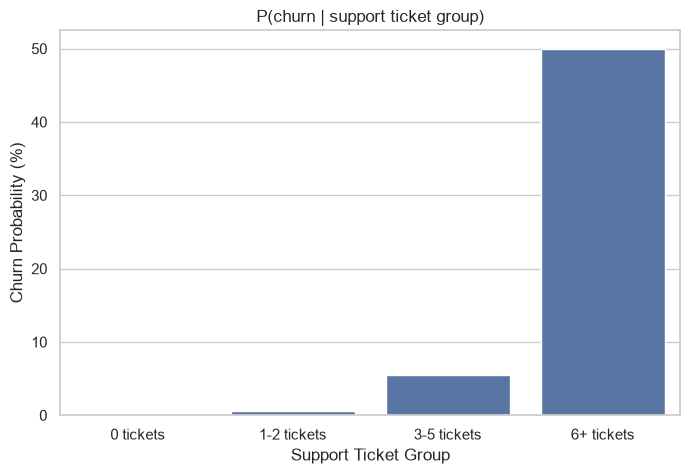

In [5]:
df["ticket_group"] = pd.cut(
    df["support_tickets"],
    bins=[-1, 0, 2, 5, 100],
    labels=["0 tickets", "1-2 tickets", "3-5 tickets", "6+ tickets"]
)

churn_by_ticket_group = df.groupby("ticket_group")["churn"].agg(["count", "mean"]).reset_index()
churn_by_ticket_group["mean"] = churn_by_ticket_group["mean"] * 100

display(churn_by_ticket_group)

plt.figure(figsize=(8, 5))
sns.barplot(data=churn_by_ticket_group, x="ticket_group", y="mean")
plt.title("P(churn | support ticket group)")
plt.xlabel("Support Ticket Group")
plt.ylabel("Churn Probability (%)")
plt.show()

# 14. Independence

Two events A and B are independent if knowing B does not change probability of A.

Formula:

```text
P(A | B) = P(A)
```

Equivalent formula:

```text
P(A and B) = P(A) × P(B)
```

Example:

If churn probability is the same for high-ticket and low-ticket customers, then churn and high tickets are independent.

But in real business data, they are usually dependent.

In [18]:
A = df["churn"] == 1
B = df["support_tickets"] >= 3

p_A = A.mean()
p_B = B.mean()
p_A_given_B = df.loc[B, "churn"].mean()
p_A_and_B = (A & B).mean()

print("P(churn):", round(p_A, 3))
print("P(high tickets):", round(p_B, 3))
print("P(churn | high tickets):", round(p_A_given_B, 3))
print("P(churn and high tickets):", round(p_A_and_B, 3))
print("P(churn) × P(high tickets):", round(p_A * p_B, 3))

if abs(p_A_given_B - p_A) < 0.02:
    print("These events look almost independent.")
else:
    print("These events do not look independent.")

P(churn): 0.018
P(high tickets): 0.258
P(churn | high tickets): 0.047
P(churn and high tickets): 0.012
P(churn) × P(high tickets): 0.005
These events do not look independent.


# 15. Simulation of independent events

Let's simulate two independent coin tosses.

Event A: first coin is heads  
Event B: second coin is heads

These should be independent.

In [20]:
n_trials = 10000

coin1 = np.random.choice(["H", "T"], size=n_trials)
coin2 = np.random.choice(["H", "T"], size=n_trials)

A = coin1 == "H"
B = coin2 == "H"

print("P(A):", A.mean().round(3))
print("P(B):", B.mean().round(3))
print("P(A | B):", A[B].mean().round(3))
print("P(A and B):", (A & B).mean().round(3))
print("P(A) × P(B):", (A.mean() * B.mean()).round(3))

P(A): 0.507
P(B): 0.504
P(A | B): 0.501
P(A and B): 0.252
P(A) × P(B): 0.256


# 16. Dependent events

Now let's simulate dependent events.

Event A: customer has high support tickets  
Event B: customer churns

Here, B depends on A because high support tickets increase churn probability.

C:\Users\malik\AppData\Local\Temp\ipykernel_15036\2901831087.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby("ticket_group")["churn"].mean().reset_index(),


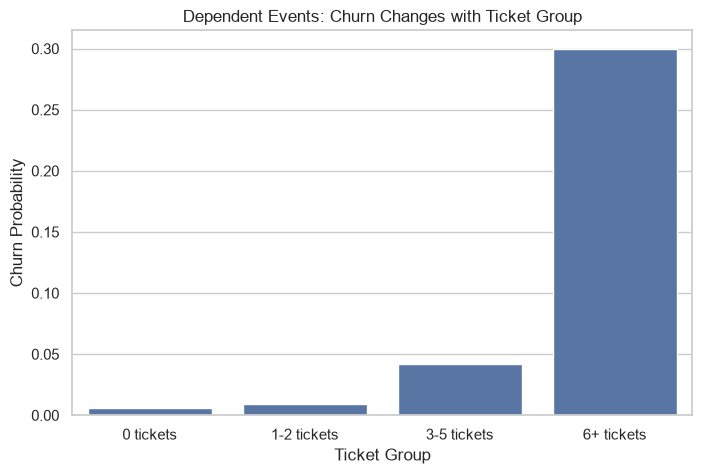

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df.groupby("ticket_group")["churn"].mean().reset_index(),
    x="ticket_group",
    y="churn"
)

plt.title("Dependent Events: Churn Changes with Ticket Group")
plt.xlabel("Ticket Group")
plt.ylabel("Churn Probability")
plt.show()

# 17. Bayes theorem

Bayes theorem helps us update probability after seeing evidence.

Formula:

```text
P(A | B) = [P(B | A) × P(A)] / P(B)
```

In ML language:

- `P(A)` = prior probability
- `P(B | A)` = likelihood
- `P(A | B)` = posterior probability
- `P(B)` = evidence

Example:

```text
A = customer will churn
B = customer has high support tickets
```

Bayes helps calculate:

```text
P(churn | high support tickets)
```

In [6]:
# Bayes theorem with churn and high support tickets

A = df["churn"] == 1
B = df["support_tickets"] >= 3

p_A = A.mean()                         # P(churn)
p_B = B.mean()                         # P(high tickets)
p_B_given_A = B[A].mean()              # P(high tickets | churn)

p_A_given_B_bayes = (p_B_given_A * p_A) / p_B
p_A_given_B_direct = A[B].mean()


print("P(churn):", round(p_A, 3))
print("P(high tickets):", round(p_B, 3))
print("P(high tickets | churn):", round(p_B_given_A, 3))
print("P(churn | high tickets) using Bayes:", round(p_A_given_B_bayes, 3))
print("P(churn | high tickets) direct:", round(p_A_given_B_direct, 3))

P(churn): 0.021
P(high tickets): 0.254
P(high tickets | churn): 0.833
P(churn | high tickets) using Bayes: 0.069
P(churn | high tickets) direct: 0.069


# 18. Bayes theorem intuition: medical test example

Suppose:

- Disease is rare: P(disease) = 1%
- Test catches disease: P(positive | disease) = 95%
- Test false positive rate: P(positive | no disease) = 5%

Question:

> If test is positive, what is P(disease | positive)?

Many people think it is 95%, but that is wrong.

Why?

Because the disease is rare, false positives can be common compared with true positives.

In [14]:
p_disease = 0.01
p_no_disease = 1 - p_disease

p_positive_given_disease = 0.95
p_positive_given_no_disease = 0.05

p_positive = (
    p_positive_given_disease * p_disease
    + p_positive_given_no_disease * p_no_disease
)

p_disease_given_positive = (p_positive_given_disease * p_disease) /p_positive

print("P(disease):", p_disease)
print("P(positive):", round(p_positive, 4))
print("P(disease | positive):", round(p_disease_given_positive, 4))
print("Percentage:", round(p_disease_given_positive * 100, 2), "%")

P(disease): 0.01
P(positive): 0.059
P(disease | positive): 0.161
Percentage: 16.1 %


# 19. Visualize Bayes theorem with counts

Counts often make Bayes easier.

Imagine 10,000 people.

- 1% have disease = 100 people
- 99% do not = 9,900 people
- 95% of diseased test positive = 95 true positives
- 5% of non-diseased test positive = 495 false positives

So among positive tests:

```text
95 / (95 + 495) ≈ 16.1%
```

This is why base rate matters.

,group,count
0,True Positive,95
1,False Positive,495


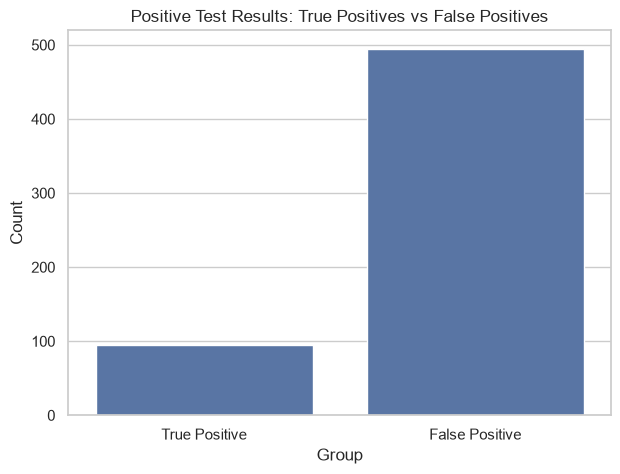

P(disease | positive): 0.16101694915254236


In [16]:
population_size = 10000

diseased = int(population_size * p_disease)
not_diseased = population_size - diseased

true_positive = int(diseased * p_positive_given_disease)
false_positive = int(not_diseased * p_positive_given_no_disease)

bayes_count_df = pd.DataFrame({
    "group": ["True Positive", "False Positive"],
    "count": [true_positive, false_positive]
})

display(bayes_count_df)

plt.figure(figsize=(7, 5))
sns.barplot(data=bayes_count_df, x="group", y="count")
plt.title("Positive Test Results: True Positives vs False Positives")
plt.xlabel("Group")

plt.ylabel("Count")
plt.show()

print("P(disease | positive):", true_positive / (true_positive + false_positive))

# 20. Expected value

Expected value is the long-run average outcome.

Formula idea:

```text
Expected value = sum(outcome × probability)
```

Example:

A business decision:

- If customer churns, loss = $500
- If customer stays, loss = $0
- Model says P(churn) = 0.30

Expected loss:

```text
0.30 × 500 + 0.70 × 0 = 150
```

Expected value helps ML systems make decisions under uncertainty.

In [ ]:
p_churn_example = 0.30
loss_if_churn = 500

expected_loss = p_churn_example * loss_if_churn + (1 - p_churn_example) * 0

print("Expected loss:", expected_loss)

# 21. Decision using expected value

Suppose we can offer a retention discount.

- Discount cost = $80
- If customer churns and we do nothing, loss = $500
- If customer accepts discount, we avoid churn loss
- Model predicts churn probability

We can use expected loss to decide whether discount is worth it.

If:

```text
P(churn) × churn_loss > discount_cost
```

Then offering discount may be rational.

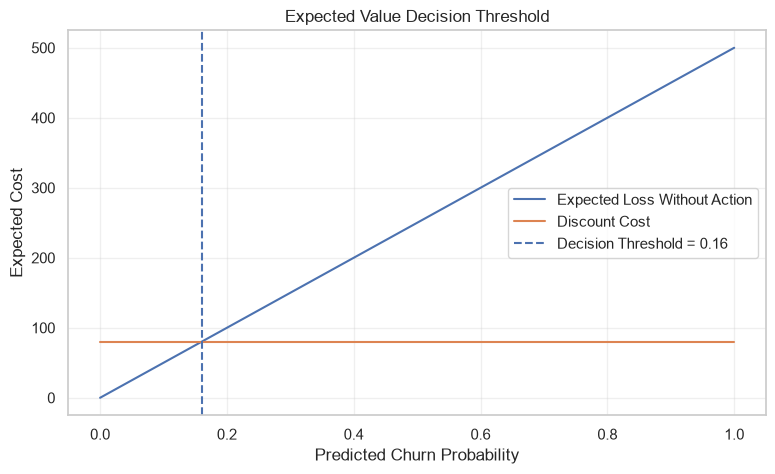

Offer discount if churn probability is greater than: 0.16


In [7]:
churn_probabilities = np.linspace(0, 1, 101)
churn_loss = 500
discount_cost = 80

expected_loss_no_action = churn_probabilities * churn_loss
expected_cost_with_discount = np.full_like(churn_probabilities, discount_cost)

decision_threshold = discount_cost / churn_loss

plt.figure(figsize=(9, 5))
plt.plot(churn_probabilities, expected_loss_no_action, label="Expected Loss Without Action")
plt.plot(churn_probabilities, expected_cost_with_discount, label="Discount Cost")
plt.axvline(decision_threshold, linestyle="--", label=f"Decision Threshold = {decision_threshold:.2f}")
plt.title("Expected Value Decision Threshold")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Expected Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Offer discount if churn probability is greater than:", round(decision_threshold, 3))

# 22. Classification probability

Now we train a simple ML classifier.

The model will output probabilities:

```text
P(churn = 1 | features)
```

Then we will use threshold-based decisions.

In [9]:
features = ["support_tickets", "satisfaction", "monthly_spend", "account_age"]
target = "churn"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_default))#.round(3))
print("Precision:", precision_score(y_test, y_pred_default, zero_division=0))#.round(3))
print("Recall:", recall_score(y_test, y_pred_default, zero_division=0))#.round(3))
print("F1:", f1_score(y_test, y_pred_default, zero_division=0))#.round(3))

Accuracy: 0.98
Precision: 0.0
Recall: 0.0
F1: 0.0


# 23. Probability distribution from model

We can visualize model confidence.

If probabilities for class 1 are mostly low, the model thinks most customers are not likely to churn.

If actual churned customers have higher probabilities than non-churned customers, the model is learning signal.

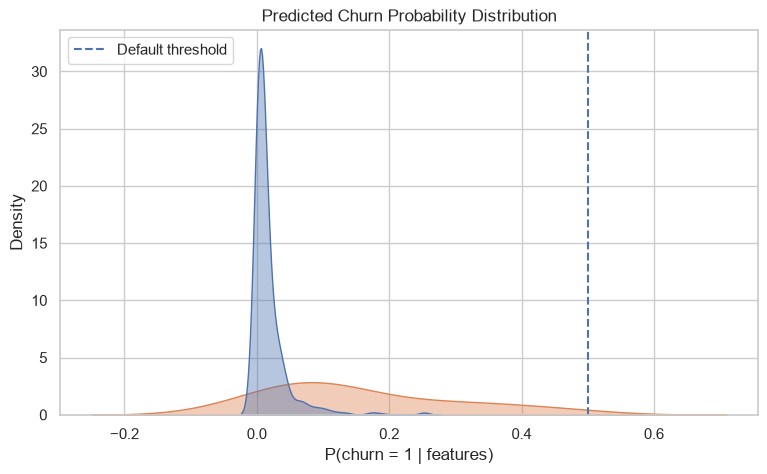

In [10]:
prob_df = pd.DataFrame({
    "actual": y_test.values,
    "churn_probability": y_proba
})

plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=prob_df,
    x="churn_probability",
    hue="actual",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.axvline(0.5, linestyle="--", label="Default threshold")
plt.title("Predicted Churn Probability Distribution")
plt.xlabel("P(churn = 1 | features)")
plt.ylabel("Density")
plt.legend()
plt.show()

# 24. Thresholds convert probabilities into decisions

A classifier may output:

```text
P(churn) = 0.42
```

But we still need a final decision:

```text
churn or not churn
```

Default threshold is usually 0.5.

But in real life, threshold depends on business cost.

Lower threshold:
- catches more churners
- increases recall
- may create more false positives

Higher threshold:
- fewer false positives
- may miss churners

,threshold,accuracy,precision,recall,f1
0,0.05,0.926,0.186,0.8,0.302
1,0.10,0.970,0.353,0.6,0.444
2,0.15,0.976,0.375,0.3,0.333
3,0.20,0.982,0.600,0.3,0.400
4,0.25,0.982,0.600,0.3,0.400
5,0.30,0.984,1.000,0.2,0.333
6,0.35,0.982,1.000,0.1,0.182
7,0.40,0.982,1.000,0.1,0.182
8,0.45,0.980,0.000,0.0,0.000
9,0.50,0.980,0.000,0.0,0.000


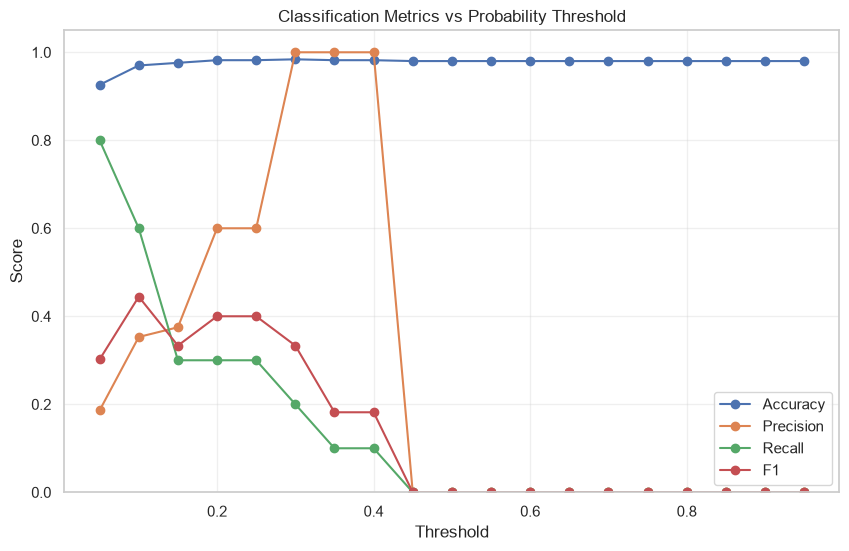

In [11]:
thresholds = np.linspace(0.05, 0.95, 19)

rows = []

for threshold in thresholds:
    preds = (y_proba >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)

display(threshold_df.round(3))

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Classification Metrics vs Probability Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 25. Interactive threshold dashboard

Now use a slider to see how the threshold affects the confusion matrix.

In [12]:
def threshold_dashboard(threshold=0.5):
    preds = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_test, preds)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.title(f"Confusion Matrix at Threshold {threshold:.2f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")

if WIDGETS_AVAILABLE:
    interact(
        threshold_dashboard,
        threshold=widgets.FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05)
    )
else:
    threshold_dashboard(0.5)

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.95, min=0.05, step=0.05), Output()…

# 26. Probability calibration intuition

If a model says 100 customers have 70% churn probability, around 70 of them should churn.

That is calibration.

A model can rank customers well but still give poorly calibrated probabilities.

Calibration is important when probabilities are used for business decisions.

C:\Users\malik\AppData\Local\Temp\ipykernel_3284\1140198327.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration_table = prob_df.groupby("prob_bin").agg(


,prob_bin,average_predicted_probability,actual_churn_rate,count
0,"(-0.001, 0.1]",0.014167,0.008282,483
1,"(0.1, 0.2]",0.134540,0.250000,12
2,"(0.2, 0.3]",0.258735,0.333333,3
3,"(0.3, 0.4]",0.324116,1.000000,1
4,"(0.4, 0.5]",0.441766,1.000000,1
5,"(0.5, 0.6]",NaN,NaN,0
6,"(0.6, 0.7]",NaN,NaN,0
7,"(0.7, 0.8]",NaN,NaN,0
8,"(0.8, 0.9]",NaN,NaN,0
9,"(0.9, 1.0]",NaN,NaN,0


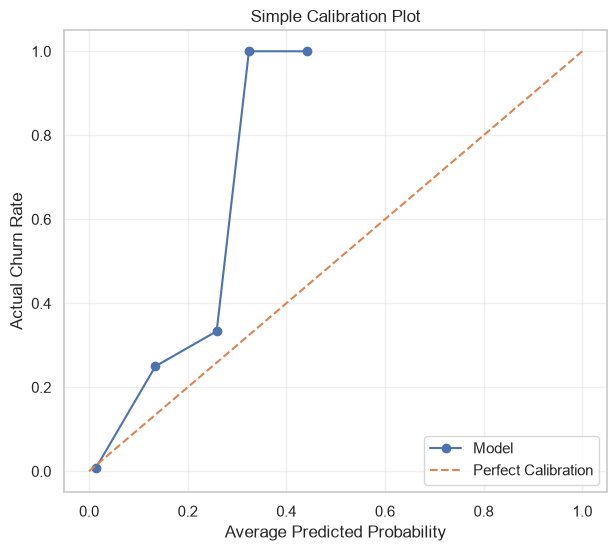

In [13]:
# Simple calibration table

prob_df["prob_bin"] = pd.cut(
    prob_df["churn_probability"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

calibration_table = prob_df.groupby("prob_bin").agg(
    average_predicted_probability=("churn_probability", "mean"),
    actual_churn_rate=("actual", "mean"),
    count=("actual", "count")
).reset_index()

display(calibration_table)

plt.figure(figsize=(7, 6))
plt.plot(
    calibration_table["average_predicted_probability"],
    calibration_table["actual_churn_rate"],
    marker="o",
    label="Model"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Simple Calibration Plot")
plt.xlabel("Average Predicted Probability")
plt.ylabel("Actual Churn Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 27. Naive Bayes intuition

Naive Bayes is a machine learning algorithm based on Bayes theorem.

It is called "naive" because it assumes features are conditionally independent given the class.

Example in spam detection:

```text
P(spam | words) ∝ P(spam) × P(word1 | spam) × P(word2 | spam) × ...
```

Even though the independence assumption is often not perfectly true, Naive Bayes can work well for text classification.

# 28. Manual Naive Bayes style spam example

Suppose we classify email as spam or not spam.

Vocabulary:

- free
- win
- meeting

We estimate probabilities from training data.

Then we compare:

```text
score_spam = P(spam) × P(words | spam)
score_not_spam = P(not spam) × P(words | not spam)
```

The larger score wins.

In [14]:
# Tiny manual probability table

p_spam = 0.40
p_not_spam = 0.60

word_probs = pd.DataFrame({
    "word": ["free", "win", "meeting"],
    "P(word|spam)": [0.70, 0.60, 0.10],
    "P(word|not_spam)": [0.10, 0.05, 0.50]
})

display(word_probs)

email_words = ["free", "win"]

score_spam = p_spam
score_not_spam = p_not_spam

for word in email_words:
    score_spam *= word_probs.loc[word_probs["word"] == word, "P(word|spam)"].iloc[0]
    score_not_spam *= word_probs.loc[word_probs["word"] == word, "P(word|not_spam)"].iloc[0]

print("Email words:", email_words)
print("Spam score:", score_spam)
print("Not spam score:", score_not_spam)

if score_spam > score_not_spam:
    print("Prediction: Spam")
else:
    print("Prediction: Not Spam")

,word,P(word|spam),P(word|not_spam)
0,free,0.7,0.10
1,win,0.6,0.05
2,meeting,0.1,0.50


Email words: ['free', 'win']
Spam score: 0.16799999999999998
Not spam score: 0.003
Prediction: Spam


# 29. Probability and risk ranking

In many ML systems, probability is used for ranking.

Example:

Instead of simply predicting churn or not churn, we rank customers by churn probability.

Then the business can target the top 50 or top 100 highest-risk customers.

In [15]:
risk_table = X_test.copy()
risk_table["actual_churn"] = y_test.values
risk_table["predicted_churn_probability"] = y_proba

risk_table = risk_table.sort_values("predicted_churn_probability", ascending=False)

display(risk_table.head(10))

top_10_percent = risk_table.head(int(0.10 * len(risk_table)))

print("Overall churn rate:", y_test.mean().round(3))
print("Churn rate in top 10% risk group:", top_10_percent["actual_churn"].mean().round(3))

,support_tickets,satisfaction,monthly_spend,account_age,actual_churn,predicted_churn_probability
561,6,19.5,61.90,72.7,1,0.441766
1198,6,30.8,42.86,12.0,1,0.324116
855,6,33.6,78.25,8.1,1,0.270063
409,5,26.6,58.58,31.7,0,0.253589
1981,5,25.8,62.85,1.0,0,0.252554
1446,5,35.8,47.03,39.5,0,0.189695
465,5,35.7,75.94,43.3,0,0.175290
895,5,37.9,50.97,32.0,0,0.172383
208,5,41.8,70.71,13.5,0,0.137684
215,5,42.9,65.02,40.0,1,0.136883


Overall churn rate: 0.02
Churn rate in top 10% risk group: 0.16


# 30. Lift

Lift compares the positive rate in a selected group to the overall positive rate.

Example:

If overall churn rate is 10%, but top 10% risk group has 30% churn:

```text
Lift = 30% / 10% = 3x
```

This means the model-selected group is 3 times more concentrated with churners.

In [16]:
overall_rate = y_test.mean()
top_rate = top_10_percent["actual_churn"].mean()
lift = top_rate / overall_rate

print("Overall churn rate:", round(overall_rate, 3))
print("Top 10% churn rate:", round(top_rate, 3))
print("Lift:", round(lift, 2), "x")

Overall churn rate: 0.02
Top 10% churn rate: 0.16
Lift: 8.0 x


# 31. Mini project — Probability-based churn decision system

Your task is to build a probability-based decision system.

## Scenario

You work for a subscription company.

The model predicts probability of churn for each customer.

The business wants to decide:

- who should receive a retention offer
- what threshold should be used
- expected cost
- expected saved loss

## Required steps

1. Train a classifier  
2. Get predicted churn probabilities  
3. Rank customers by probability  
4. Create threshold-based predictions  
5. Calculate confusion matrix  
6. Calculate precision, recall, and F1  
7. Calculate expected loss without action  
8. Calculate cost of retention offer  
9. Decide when offer is worth it  
10. Write insights  

## Important idea

The best threshold is not always 0.5.

The best threshold depends on business cost.

In [ ]:
# Mini project starter

retention_offer_cost = 80
churn_loss = 500

decision_threshold = retention_offer_cost / churn_loss

print("Retention offer cost:", retention_offer_cost)
print("Churn loss:", churn_loss)
print("Business decision threshold:", round(decision_threshold, 3))

risk_table["send_offer"] = risk_table["predicted_churn_probability"] >= decision_threshold

display(risk_table.head())

print("Customers receiving offer:", risk_table["send_offer"].sum())
print("Percent receiving offer:", round(risk_table["send_offer"].mean() * 100, 2), "%")

In [ ]:
# Estimate expected cost

risk_table["expected_loss_no_action"] = risk_table["predicted_churn_probability"] * churn_loss
risk_table["expected_cost_with_offer"] = retention_offer_cost

risk_table["expected_saving"] = (
    risk_table["expected_loss_no_action"] - risk_table["expected_cost_with_offer"]
)

display(risk_table[[
    "predicted_churn_probability",
    "send_offer",
    "expected_loss_no_action",
    "expected_cost_with_offer",
    "expected_saving"
]].head(10))

total_expected_saving = risk_table.loc[risk_table["send_offer"], "expected_saving"].sum()

print("Total expected saving from selected offers:", round(total_expected_saving, 2))

# 32. Practice questions

Answer these in your own words.

1. What is a random experiment?
2. What is a sample space?
3. What is an event?
4. What does probability mean in ML?
5. What is the complement rule?
6. What is the difference between union and intersection?
7. Why do we subtract intersection in the addition rule?
8. What is conditional probability?
9. What does P(churn | high tickets) mean?
10. What does independence mean?
11. How can we check if two events are independent?
12. What is Bayes theorem?
13. What is prior probability?
14. What is likelihood?
15. What is posterior probability?
16. Why does base rate matter?
17. What is expected value?
18. Why does threshold matter in classification?
19. What is probability calibration?
20. What is lift?
21. Why is ranking by probability useful?
22. Why is the best threshold not always 0.5?

# 33. What we learned

In this notebook, we learned:

- Probability measures uncertainty
- ML classifiers often estimate conditional probabilities
- Random experiments have sample spaces and events
- Complement rule calculates probability of not happening
- Union means A or B
- Intersection means A and B
- Conditional probability means probability given evidence
- Events are independent if one does not change probability of the other
- Bayes theorem updates belief using evidence
- Base rates are very important
- Expected value helps make decisions under uncertainty
- Classifier probabilities can be converted to decisions using thresholds
- Threshold choice affects precision and recall
- Probability calibration checks whether predicted probabilities match real outcomes
- Naive Bayes is based on Bayes theorem
- Risk ranking and lift are useful in business ML systems

---

# Next Notebook

Notebook 3 will cover:

# Probability Distributions for Machine Learning

We will learn:

- Bernoulli distribution
- Binomial distribution
- Normal distribution
- Standard normal distribution
- Poisson distribution
- Exponential distribution
- Log-normal distribution
- how distributions appear in real ML data
- how to simulate distributions
- how distributions guide feature engineering

# 32. Practice Questions — Probability for Machine Learning

## 1. What is a random experiment?

A **random experiment** is a process whose exact result cannot be known before it happens, although we know the possible outcomes.

Examples:

- Tossing a coin
- Rolling a dice
- Predicting whether a customer will churn
- Predicting whether an email is spam

---

## 2. What is a sample space?

A **sample space** is the collection of all possible outcomes of a random experiment.

It is usually represented by \(S\).

For a coin toss:

\[
S = \{H, T\}
\]

For a six-sided dice:

\[
S = \{1,2,3,4,5,6\}
\]

For a churn problem:

\[
S = \{\text{Churn}, \text{Not Churn}\}
\]

---

## 3. What is an event?

An **event** is one outcome or a group of outcomes from the sample space.

For a dice roll:

\[
S = \{1,2,3,4,5,6\}
\]

The event of rolling an even number is:

\[
A = \{2,4,6\}
\]

An event is therefore a subset of the sample space.

---

## 4. What does probability mean in ML?

In machine learning, **probability** represents how likely a model believes an outcome is.

For example:

\[
P(\text{Churn}) = 0.80
\]

This means the model estimates an 80% chance that the customer will churn.

Probability values range between 0 and 1:

\[
0 \leq P(A) \leq 1
\]

- \(0\) means impossible.
- \(1\) means certain.
- A value near \(0.5\) means the model is uncertain.

---

## 5. What is the complement rule?

The **complement** of an event means that the event does not happen.

If \(A\) is an event, its complement is written as \(A^c\).

The complement rule is:

\[
P(A^c) = 1 - P(A)
\]

For example, if:

\[
P(\text{Churn}) = 0.30
\]

then:

\[
P(\text{Not Churn}) = 1 - 0.30 = 0.70
\]

The probability of an event and its complement always adds up to 1.

---

## 6. What is the difference between union and intersection?

### Union

The union of events \(A\) and \(B\) means that **A happens, B happens, or both happen**.

It is written as:

\[
A \cup B
\]

For example:

- \(A\): Customer has high support tickets.
- \(B\): Customer has made a late payment.

Then \(A \cup B\) means the customer has high support tickets, a late payment, or both.

### Intersection

The intersection of \(A\) and \(B\) means that **both events happen together**.

It is written as:

\[
A \cap B
\]

Here, \(A \cap B\) means the customer has both high support tickets and a late payment.

---

## 7. Why do we subtract intersection in the addition rule?

The addition rule is:

\[
P(A \cup B) = P(A) + P(B) - P(A \cap B)
\]

When we add \(P(A)\) and \(P(B)\), the outcomes that belong to both events are counted twice:

- Once in \(P(A)\)
- Once in \(P(B)\)

We subtract \(P(A \cap B)\) once to remove this duplicate counting.

For example:

\[
P(A) = 0.50
\]

\[
P(B) = 0.40
\]

\[
P(A \cap B) = 0.20
\]

Therefore:

\[
P(A \cup B) = 0.50 + 0.40 - 0.20 = 0.70
\]

---

## 8. What is conditional probability?

**Conditional probability** is the probability of an event happening when we already know that another event has happened.

It is written as:

\[
P(A \mid B)
\]

It is read as:

> The probability of A given B.

The formula is:

\[
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
\]

For example, we may calculate the probability that a customer churns given that the customer has many support tickets.

---

## 9. What does \(P(\text{churn} \mid \text{high tickets})\) mean?

\[
P(\text{churn} \mid \text{high tickets})
\]

means:

> The probability that a customer will churn, given that the customer has a high number of support tickets.

We only examine customers who have high support tickets.

Suppose 200 customers have high support tickets and 120 of them churned:

\[
P(\text{churn} \mid \text{high tickets})
=
\frac{120}{200}
=
0.60
\]

This means that 60% of customers with high support tickets churned.

---

## 10. What does independence mean?

Two events are **independent** when one event happening does not change the probability of the other event.

For independent events:

\[
P(A \mid B) = P(A)
\]

This means that knowing \(B\) happened gives us no extra information about \(A\).

For example, a customer's churn and the result of an unrelated coin toss are independent.

---

## 11. How can we check if two events are independent?

Two events \(A\) and \(B\) are independent if:

\[
P(A \cap B) = P(A)P(B)
\]

We can also check whether:

\[
P(A \mid B) = P(A)
\]

For example, suppose:

\[
P(A) = 0.50
\]

\[
P(B) = 0.40
\]

If the events are independent, their intersection should be:

\[
P(A \cap B) = 0.50 \times 0.40 = 0.20
\]

If the actual intersection is also \(0.20\), the events are independent.

---

## 12. What is Bayes' theorem?

**Bayes' theorem** is used to update the probability of an event or hypothesis after receiving new evidence.

The formula is:

\[
P(A \mid B)
=
\frac{P(B \mid A)P(A)}{P(B)}
\]

It can also be understood as:

\[
\text{Posterior}
=
\frac{\text{Likelihood} \times \text{Prior}}
{\text{Evidence}}
\]

For example, Bayes' theorem can update the probability that a transaction is fraudulent after unusual activity is observed.

---

## 13. What is prior probability?

The **prior probability** is our initial belief about an event before considering new evidence.

It is written as:

\[
P(A)
\]

For example, if 2% of all transactions are fraudulent, then:

\[
P(\text{Fraud}) = 0.02
\]

This is the starting probability before examining a particular transaction.

---

## 14. What is likelihood?

The **likelihood** tells us how probable the observed evidence is when a particular hypothesis is true.

It is represented as:

\[
P(B \mid A)
\]

For example:

\[
P(\text{Unusual Activity} \mid \text{Fraud})
\]

means the probability of observing unusual activity when the transaction is actually fraudulent.

Likelihood asks:

> If the hypothesis is true, how likely is this evidence?

---

## 15. What is posterior probability?

The **posterior probability** is the updated probability of a hypothesis after considering new evidence.

It is represented as:

\[
P(A \mid B)
\]

For example:

\[
P(\text{Fraud} \mid \text{Unusual Activity})
\]

is the updated probability that a transaction is fraudulent after observing unusual activity.

The posterior combines the prior probability with the new evidence.

---

## 16. Why does the base rate matter?

The **base rate** is the overall frequency of an event in the population.

For example, suppose only 1% of all transactions are fraudulent.

Even if a fraud detection system is accurate, many alerts may still be false because fraud is naturally very rare.

Ignoring the base rate can make us overestimate the probability of rare events.

Bayes' theorem considers both:

- How strongly the evidence supports the event
- How common the event normally is

---

## 17. What is expected value?

The **expected value** is the long-term average result of a random process.

It is calculated by multiplying each possible outcome by its probability and adding the results:

\[
E(X) = \sum x_iP(x_i)
\]

For example, suppose a business decision has:

- A 70% chance of earning \$100
- A 30% chance of losing \$50

Then:

\[
E(X) = (100 \times 0.70) + (-50 \times 0.30)
\]

\[
E(X) = 70 - 15 = 55
\]

The expected value is \$55.

Expected value helps compare decisions using both probability and business value.

---

## 18. Why does threshold matter in classification?

A classification model usually produces a probability before producing a class.

For example:

\[
P(\text{Churn}) = 0.70
\]

A threshold converts this probability into a class.

With a threshold of \(0.50\):

\[
0.70 \geq 0.50
\]

The customer is classified as churn.

Changing the threshold changes:

- The number of positive predictions
- False positives
- False negatives
- Precision
- Recall
- Business cost

A lower threshold produces more positive predictions, while a higher threshold produces fewer positive predictions.

---

## 19. What is probability calibration?

**Probability calibration** measures whether a model's predicted probabilities match actual real-world frequencies.

For example, among all cases where a well-calibrated model predicts a probability of approximately 0.80, around 80% should actually belong to the positive class.

A model can have good classification accuracy but poorly calibrated probabilities.

Calibration is important when probabilities are used for:

- Risk estimation
- Medical decisions
- Fraud detection
- Financial decisions
- Customer prioritization

---

## 20. What is lift?

**Lift** measures how much better a model is at finding positive cases compared with random selection.

The formula is:

\[
\text{Lift}
=
\frac{\text{Positive rate in selected group}}
{\text{Positive rate in total population}}
\]

Suppose:

- The overall churn rate is 10%.
- The churn rate among the highest-risk customers is 30%.

Then:

\[
\text{Lift}
=
\frac{0.30}{0.10}
=
3
\]

A lift of 3 means the selected group contains churners at three times the normal population rate.

---

## 21. Why is ranking by probability useful?

Ranking observations by predicted probability places the highest-risk or highest-opportunity cases first.

For example, a churn model can rank customers from the highest churn probability to the lowest.

This is useful when a company has limited resources.

Instead of contacting every customer, it can focus on the customers who are most likely to churn.

Probability ranking is commonly used for:

- Selecting customers for marketing campaigns
- Prioritizing fraud investigations
- Ranking loan applicants by risk
- Prioritizing medical cases
- Recommending products
- Selecting strong sales leads

---

## 22. Why is the best threshold not always 0.5?

A threshold of \(0.5\) is only a default value.

It does not automatically consider:

- Class imbalance
- Business cost
- False-positive cost
- False-negative cost
- Available resources
- Required precision
- Required recall

For example, in fraud detection, missing a fraudulent transaction may be much more expensive than investigating a legitimate transaction.

Therefore, we may use a lower threshold such as:

\[
0.20
\]

This detects more fraud cases but may also create more false alarms.

The best threshold should be selected using validation data and according to the goal of the problem.


# Probability Foundations

## Random Experiment

A **random experiment** is a process whose exact outcome is uncertain before the experiment is performed.

Examples:

- Tossing a coin
- Rolling a die
- Predicting whether a customer will churn
- Predicting whether a transaction is fraudulent

Although we do not know the exact outcome beforehand, we normally know all possible outcomes.

---

## Sample Space

A **sample space** is the set of all possible outcomes of a random experiment.

It is represented by \(S\).

For a six-sided die:

\[
S = \{1,2,3,4,5,6\}
\]

---

## Event

An **event** is one outcome or a subset of outcomes from the sample space.

For example, suppose event \(A\) represents rolling an even number:

\[
A = \{2,4,6\}
\]

Because these outcomes belong to the sample space, event \(A\) is a subset of \(S\).

---

## Probability of an Event

When all outcomes are equally likely, the probability of an event is:

\[
P(A)
=
\frac{\text{Number of favourable outcomes}}
{\text{Total number of possible outcomes}}
\]

For a fair six-sided die, the probability of rolling an even number is:

\[
P(\text{Even})
=
\frac{3}{6}
=
0.5
\]

The favourable outcomes are:

\[
\{2,4,6\}
\]

The probability of rolling exactly 1 is:

\[
P(1)
=
\frac{1}{6}
\]

This formula should only be used when all possible outcomes are equally likely.

---

## Theoretical Probability vs Simulated Probability

**Theoretical probability** is calculated mathematically.

For a fair die:

\[
P(\text{Even})
=
\frac{3}{6}
=
0.5
\]

**Simulated probability**, also called **experimental probability**, is calculated by repeating an experiment and observing how often the event occurs.

\[
P_{\text{simulated}}(A)
=
\frac{\text{Number of times event A occurs}}
{\text{Total number of trials}}
\]

Suppose we roll a die 10 times and obtain an even number 3 times:

\[
P_{\text{simulated}}(\text{Even})
=
\frac{3}{10}
=
0.3
\]

The simulated probability \(0.3\) is different from the theoretical probability \(0.5\).

This does not mean the theoretical probability is wrong. It means that a small number of trials can produce results that are far from the theoretical probability.

---

## Law of Large Numbers

The **law of large numbers** states that as the number of trials increases, the simulated probability usually gets closer to the theoretical probability.

For example:

- After 10 rolls, the simulated probability may be \(0.3\).
- After 100 rolls, it may become \(0.46\).
- After 1,000 rolls, it may become \(0.498\).
- After 100,000 rolls, it may become very close to \(0.5\).

Therefore:

\[
\text{More trials}
\Rightarrow
\text{Simulated probability gets closer to theoretical probability}
\]

The simulated probability does not have to become exactly equal to the theoretical probability. It generally becomes closer as the number of experiments increases.

---

## Complement Rule

The **complement** of event \(A\) means that event \(A\) does not happen.

The complement is written as:

\[
A^c
\]

The complement rule is:

\[
P(A^c)
=
1-P(A)
\]

For example, suppose:

\[
P(\text{Churn})
=
0.30
\]

Then:

\[
P(\text{Not Churn})
=
1-0.30
=
0.70
\]

An event and its complement cover all possible outcomes:

\[
P(A)+P(A^c)=1
\]

---

## Union and Intersection

Suppose:

- \(A\): The customer is premium.
- \(B\): The customer churns.

### Intersection

The intersection means that both events happen together.

It is written as:

\[
A \cap B
\]

Therefore:

\[
P(A \cap B)
\]

means the probability that a customer is both premium and churns.

It can also be read as:

\[
P(A \text{ and } B)
\]

For independent events:

\[
P(A\cap B)
=
P(A)P(B)
\]

For dependent events:

\[
P(A\cap B)
=
P(A)P(B\mid A)
\]

The formula \(P(A\cap B)=P(A)P(B)\) should only be used when the events are independent.

### Union

The union means that event \(A\), event \(B\), or both events happen.

It is written as:

\[
A \cup B
\]

Therefore:

\[
P(A\cup B)
\]

means the probability that a customer is premium, churns, or is both premium and churns.

It can also be read as:

\[
P(A \text{ or } B)
\]

---

## Addition Rule

The addition rule calculates the probability of the union of two events:

\[
P(A\cup B)
=
P(A)+P(B)-P(A\cap B)
\]

We subtract the intersection because the outcomes belonging to both events are counted twice when we add:

\[
P(A)+P(B)
\]

They are counted once in \(P(A)\) and once in \(P(B)\).

Subtracting \(P(A\cap B)\) removes the duplicate counting.

---

## Conditional Probability

**Conditional probability** is the probability of event \(A\) happening when we already know that event \(B\) has happened.

It is written as:

\[
P(A\mid B)
\]

It is read as:

> The probability of A given B.

The formula is:

\[
P(A\mid B)
=
\frac{P(A\cap B)}{P(B)}
\]

For example:

\[
P(\text{Churn}\mid\text{Premium})
\]

means:

> The probability that a customer churns, given that the customer is premium.

When calculating this probability, we only consider premium customers.

Suppose there are 200 premium customers and 40 of them churn:

\[
P(\text{Churn}\mid\text{Premium})
=
\frac{40}{200}
=
0.20
\]

Therefore, 20% of premium customers churned.

---

## Independence

Two events \(A\) and \(B\) are **independent** when one event happening does not change the probability of the other event.

For independent events:

\[
P(A\mid B)
=
P(A)
\]

This means that knowing event \(B\) happened gives us no additional information about event \(A\).

We can check independence using:

\[
P(A\cap B)
=
P(A)P(B)
\]

If both sides are equal, the events are independent.

If they are not equal, the events are dependent.

### Independent events

\[
P(A\cap B)
=
P(A)P(B)
\]

### Dependent events

\[
P(A\cap B)
=
P(A)P(B\mid A)
\]

For example, customer churn and the number of support complaints may be dependent because having many complaints may change the probability of churn.

Customer churn and the result of an unrelated coin toss would normally be independent.

---

## Bayes' Theorem

**Bayes' theorem** helps us update the probability of an event or hypothesis after observing new evidence.

The formula is:

\[
P(A\mid B)
=
\frac{P(B\mid A)P(A)}{P(B)}
\]

It can also be understood as:

\[
\text{Posterior}
=
\frac{\text{Likelihood}\times\text{Prior}}
{\text{Evidence}}
\]

Where:

- \(P(A)\) is the **prior probability**.
- \(P(B\mid A)\) is the **likelihood**.
- \(P(B)\) is the overall probability of the evidence.
- \(P(A\mid B)\) is the **posterior probability**.

For example:

- \(A\): A customer will churn.
- \(B\): The customer has many support tickets.

Bayes' theorem helps calculate:

\[
P(\text{Churn}\mid\text{High Support Tickets})
\]

It updates the original probability of churn after observing the new evidence.

---

## Expected Value

The **expected value** is the average outcome we expect if an experiment is repeated many times.

It is also called the **long-run average**.

The expected value is calculated as:

\[
E(X)
=
\sum x_iP(x_i)
\]

This means:

1. Multiply each possible outcome by its probability.
2. Add all the results together.

Expected value does not tell us what will happen in one individual trial.

It tells us what we expect to happen on average after many trials.

For example, when rolling a fair six-sided die:

\[
E(X)
=
1\left(\frac{1}{6}\right)
+
2\left(\frac{1}{6}\right)
+
3\left(\frac{1}{6}\right)
+
4\left(\frac{1}{6}\right)
+
5\left(\frac{1}{6}\right)
+
6\left(\frac{1}{6}\right)
\]

\[
E(X)
=
\frac{1+2+3+4+5+6}{6}
=
\frac{21}{6}
=
3.5
\]

It is impossible to roll \(3.5\) in one die roll.

The value \(3.5\) means that after thousands of rolls, the average of the outcomes will approach \(3.5\).

For example:

- First roll: \(2\)
- Second roll: \(6\)
- Third roll: \(1\)

Individual outcomes vary, but their long-run average approaches the expected value.

In machine learning and business, expected value helps us make the best decision on average across many similar cases rather than trying to predict exactly what will happen for one individual customer.
```
